# CrossEnrich Pipline

Paste or load a gene list, run the CrossEnrich pipeline, and inspect the preliminary outputs.


In [3]:
# Run this once if your notebook kernel is missing dependencies.
%pip install -U pandas gprofiler-official sentence-transformers scikit-learn scipy matplotlib seaborn


Note: you may need to restart the kernel to use updated packages.


In [4]:
from pathlib import Path
import re
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from gprofiler import GProfiler

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.append(str(SRC_DIR))

from crossenrich.standardization import (
    clear_user_term_replacements,
    standardize_results_frame,
    update_user_term_replacements,
)
from crossenrich.semantic import (
    build_cluster_consistency_matrix,
    build_semantic_similarity_matrix,
    cluster_terms,
)


## 1. Add Your Gene List

Use one of these:

- paste genes directly into `GENE_LIST`
- load a CSV/TXT file with `GENE_LIST_FILE`
- load a GMT file with `GMT_FILE` and choose one gene set with `GMT_GENE_SET_NAME`


In [15]:
# Option A: paste genes here.
GENE_LIST = [
    "TP53", "MDM2", "CDKN1A", "BAX", "BBC3", "PMAIP1", "GADD45A", "GADD45B",
    "SESN1", "SESN2", "RRM2B", "DRAM1", "FAS", "TNFRSF10B", "APAF1",
    "CASP3", "CASP9", "CYCS", "PTEN", "ATM", "ATR", "BRCA1", "BRCA2",
]

# Option B: load genes from a CSV or TXT file. Leave as None if not using it.
GENE_LIST_FILE = None
GENE_COLUMN = "gene"

# Option C: load one gene set from a GMT file. Leave GMT_FILE as None if not using it.
GMT_FILE = "HALLMARK_TNFA_SIGNALING_VIA_NFKB.v2026.1.Hs.gmt"
GMT_GENE_SET_NAME = None

# If GMT_GENE_SET_NAME is None, the loader prints available gene sets and uses the first one.
# Example:
# GMT_FILE = "/path/to/h.all.v2024.1.Hs.symbols.gmt"
# GMT_GENE_SET_NAME = "HALLMARK_APOPTOSIS"

ORGANISM = "hsapiens"
SIMILARITY_THRESHOLD = 0.4
CROSS_SOURCE_ONLY = False

# Optional manual replacements used during standardization.
# Example: {"apoptosis": "cell death"}
USER_REPLACEMENTS = {}


In [16]:
def load_gmt_gene_sets(gmt_file):
    gene_sets = {}

    with Path(gmt_file).open() as handle:
        for line in handle:
            parts = line.strip().split("\t")
            if len(parts) < 3:
                continue

            gene_set_name = parts[0]
            description = parts[1]
            genes = parts[2:]

            gene_sets[gene_set_name] = {
                "description": description,
                "genes": genes,
            }

    if not gene_sets:
        raise ValueError(f"No gene sets found in GMT file: {gmt_file}")

    return gene_sets


def clean_gene_list(genes):
    cleaned = []
    seen = set()

    for gene in genes:
        gene = str(gene).strip()
        if gene and gene not in seen:
            cleaned.append(gene)
            seen.add(gene)

    if not cleaned:
        raise ValueError("No genes found.")

    return cleaned


def load_gene_list(
    gene_list=None,
    gene_list_file=None,
    gene_column="gene",
    gmt_file=None,
    gmt_gene_set_name=None,
):
    if gmt_file is not None:
        gene_sets = load_gmt_gene_sets(gmt_file)

        if gmt_gene_set_name is None:
            print("Available GMT gene sets:")
            for name in list(gene_sets)[:25]:
                print("-", name)
            if len(gene_sets) > 25:
                print(f"... and {len(gene_sets) - 25} more")

            gmt_gene_set_name = next(iter(gene_sets))
            print(f"Using first GMT gene set: {gmt_gene_set_name}")

        if gmt_gene_set_name not in gene_sets:
            matches = [
                name for name in gene_sets
                if gmt_gene_set_name.lower() in name.lower()
            ]
            raise ValueError(
                f"Gene set not found: {gmt_gene_set_name}. "
                f"Close matches: {matches[:10]}"
            )

        genes = gene_sets[gmt_gene_set_name]["genes"]
        print(f"Loaded GMT gene set: {gmt_gene_set_name}")
        print(f"Description: {gene_sets[gmt_gene_set_name]['description']}")

    elif gene_list_file is not None:
        path = Path(gene_list_file)
        if path.suffix.lower() == ".csv":
            genes = pd.read_csv(path)[gene_column].dropna().tolist()
        else:
            text = path.read_text()
            genes = [token for token in re.split(r"[\s,;]+", text) if token]

    else:
        genes = gene_list or []

    return clean_gene_list(genes)


## 2. Run The Pipeline

This calls g:Profiler, standardizes the result table, builds the term-term similarity matrix, clusters terms, and builds the database consistency matrix.


In [17]:
def run_crossenrich_pipeline(
    gene_list,
    *,
    organism="hsapiens",
    similarity_threshold=0.4,
    cross_source_only=False,
    user_replacements=None,
):
    clear_user_term_replacements()
    if user_replacements:
        update_user_term_replacements(user_replacements)

    gp = GProfiler()
    raw_results = pd.DataFrame(
        gp.profile(gene_list, organism=organism, no_evidences=False)
    )

    standardized = standardize_results_frame(raw_results)

    semantic_similarity = build_semantic_similarity_matrix(
        standardized.copy(),
        cross_source_only=cross_source_only,
    )

    clustered = cluster_terms(
        standardized,
        similarity_threshold=similarity_threshold,
        method="hierarchical",
        cross_source_only=True,
    )

    cluster_consistency = build_cluster_consistency_matrix(clustered)

    return {
        "gene_list": gene_list,
        "raw_results": raw_results,
        "standardized": standardized,
        "semantic_similarity": semantic_similarity,
        "clustered": clustered,
        "cluster_consistency": cluster_consistency,
    }


genes = load_gene_list(
    GENE_LIST,
    GENE_LIST_FILE,
    GENE_COLUMN,
    gmt_file=GMT_FILE,
    gmt_gene_set_name=GMT_GENE_SET_NAME,
)
pipeline = run_crossenrich_pipeline(
    genes,
    organism=ORGANISM,
    similarity_threshold=SIMILARITY_THRESHOLD,
    cross_source_only=CROSS_SOURCE_ONLY,
    user_replacements=USER_REPLACEMENTS,
)

results = pipeline["raw_results"]
frame = pipeline["standardized"]
semantic_similarity = pipeline["semantic_similarity"]
cluster = pipeline["clustered"]
cluster_consistency = pipeline["cluster_consistency"]

print(f"Genes: {len(genes)}")
print(f"Raw enrichment rows: {len(results)}")
print(f"Standardized rows: {len(frame)}")


Available GMT gene sets:
- HALLMARK_TNFA_SIGNALING_VIA_NFKB
Using first GMT gene set: HALLMARK_TNFA_SIGNALING_VIA_NFKB
Loaded GMT gene set: HALLMARK_TNFA_SIGNALING_VIA_NFKB
Description: https://www.gsea-msigdb.org/gsea/msigdb/human/geneset/HALLMARK_TNFA_SIGNALING_VIA_NFKB
Genes: 200
Raw enrichment rows: 1305
Standardized rows: 1100


## 3. Preliminary Results


In [18]:
print("Raw g:Profiler results:")
display(results.head(20))


Raw g:Profiler results:


,description,effective_domain_size,intersection_size,intersections,name,native,p_value,parents,precision,query,query_size,recall,significant,source,term_size,evidences
0,"""Any process that results in a change in state...",21026,72,"[ABCA1, ACKR3, BIRC2, BIRC3, CCL2, CCL20, CCL4...",response to peptide,GO:1901652,6.456820e-42,[GO:0042221],0.360000,query_1,200,0.074844,True,GO:BP,962,"[[IEA], [IMP], [TAS, IEA], [TAS], [IDA, IEP, I..."
1,"""Any process that results in a change in state...",21026,71,"[ABCA1, ACKR3, BIRC2, BIRC3, CCL2, CCL20, CCL4...",response to cytokine,GO:0034097,2.788886e-41,[GO:1901652],0.355000,query_1,200,0.074974,True,GO:BP,947,"[[IEA], [IMP], [TAS, IEA], [TAS], [IDA, IEP, I..."
2,"""Any process involved in the development or fu...",21026,111,"[ACKR3, B4GALT1, BCL3, BCL6, BIRC2, BIRC3, CCL...",immune system process,GO:0002376,2.915791e-41,[GO:0008150],0.555000,query_1,200,0.038662,True,GO:BP,2871,"[[IBA], [IEA], [IEA], [IMP, IBA, NAS, IEA], [T..."
3,"""The immediate defensive reaction (by vertebra...",21026,68,"[B4GALT1, BCL6, BIRC2, BIRC3, BMP2, CCL2, CCL2...",inflammatory response,GO:0006954,1.132376e-40,[GO:0006952],0.340000,query_1,200,0.078886,True,GO:BP,862,"[[IEA], [IBA, IEA], [TAS], [TAS], [ISS, IEA], ..."
4,"""Any process that results in a change in state...",21026,126,"[ABCA1, ACKR3, AREG, ATF3, B4GALT1, BCL2A1, BC...",response to stress,GO:0006950,3.760382e-40,[GO:0050896],0.630000,query_1,200,0.031915,True,GO:BP,3948,"[[IDA], [IMP], [IEA], [IDA, IEA], [IEA], [IBA]..."
5,"""Any process that modulates the frequency, rat...",21026,109,"[ABCA1, ATP2B1, B4GALT5, BCL3, BCL6, BHLHE40, ...",regulation of multicellular organismal process,GO:0051239,3.132062e-38,"[GO:0032501, GO:0050789]",0.545000,query_1,200,0.036874,True,GO:BP,2956,"[[ISS, TAS, IEA], [ISS, TAS, IEA], [ISS, IEA],..."
6,"""Any process that results in a change in state...",21026,122,"[ABCA1, ACKR3, AREG, ATP2B1, BIRC2, BIRC3, BTG...",response to chemical,GO:0042221,3.641529e-37,[GO:0050896],0.610000,query_1,200,0.031210,True,GO:BP,3909,"[[NAS, IEA], [IMP, IBA, IEA], [IEA], [IMP], [T..."
7,"""Any process that results in a change in state...",21026,98,"[ABCA1, ACKR3, BCL3, BCL6, BHLHE40, BIRC2, BIR...",response to external stimulus,GO:0009605,1.471233e-36,[GO:0050896],0.490000,query_1,200,0.040580,True,GO:BP,2415,"[[IEA], [IBA, IEA], [IDA, IEA], [IBA, IEA], [I..."
8,"""Any process that modulates the frequency, rat...",21026,81,"[BCL6, BIRC2, BIRC3, CCL2, CCL20, CCL4, CCL5, ...",regulation of immune system process,GO:0002682,9.354397e-36,"[GO:0002376, GO:0050789]",0.405000,query_1,200,0.051233,True,GO:BP,1581,"[[IMP, IBA, NAS, IEA], [TAS], [TAS], [IDA, ISS..."
9,"""Any process that modulates the frequency, rat...",21026,79,"[ACKR3, ATF3, B4GALT1, BCL2A1, BCL3, BCL6, BIR...",regulation of programmed cell death,GO:0043067,2.142918e-35,"[GO:0012501, GO:0050794]",0.395000,query_1,200,0.052457,True,GO:BP,1506,"[[IMP], [IMP], [IEA], [ISS, TAS, IEA], [IDA, I..."


In [19]:
print("Standardized results:")
display(
    frame[
        [
            "canonical_source",
            "native",
            "name",
            "standardized_name",
            "resolved_name",
            "p_value",
            "rank_within_source",
            "intersection_genes",
            "term_tokens",
        ]
    ].head(30)
)


Standardized results:


,canonical_source,native,name,standardized_name,resolved_name,p_value,rank_within_source,intersection_genes,term_tokens
0,GO:BP,GO:1901652,response to peptide,response to peptide,response to peptide,6.456820e-42,1,"(ABCA1, ACKR3, BIRC2, BIRC3, CCL2, CCL20, CCL4...","(response, peptide)"
1,GO:BP,GO:0034097,response to cytokine,response to cytokine,response to cytokine,2.788886e-41,2,"(ABCA1, ACKR3, BIRC2, BIRC3, CCL2, CCL20, CCL4...","(response, cytokine)"
2,GO:BP,GO:0002376,immune system process,immune system process,immune system process,2.915791e-41,3,"(ACKR3, B4GALT1, BCL3, BCL6, BIRC2, BIRC3, CCL...","(immune, system, process)"
3,GO:BP,GO:0006954,inflammatory response,inflammatory response,inflammatory response,1.132376e-40,4,"(B4GALT1, BCL6, BIRC2, BIRC3, BMP2, CCL2, CCL2...","(inflammatory, response)"
4,GO:BP,GO:0006950,response to stress,response to stress,response to stress,3.760382e-40,5,"(ABCA1, ACKR3, AREG, ATF3, B4GALT1, BCL2A1, BC...","(response, stress)"
5,GO:BP,GO:0051239,regulation of multicellular organismal process,regulation of multicellular organismal process,regulation of multicellular organismal process,3.132062e-38,6,"(ABCA1, ATP2B1, B4GALT5, BCL3, BCL6, BHLHE40, ...","(regulation, multicellular, organismal, process)"
6,GO:BP,GO:0042221,response to chemical,response to chemical,response to chemical,3.641529e-37,7,"(ABCA1, ACKR3, AREG, ATP2B1, BIRC2, BIRC3, BTG...","(response, chemical)"
7,GO:BP,GO:0009605,response to external stimulus,response to external stimulus,response to external stimulus,1.471233e-36,8,"(ABCA1, ACKR3, BCL3, BCL6, BHLHE40, BIRC2, BIR...","(response, external, stimulus)"
8,GO:BP,GO:0002682,regulation of immune system process,regulation of immune system process,regulation of immune system process,9.354397e-36,9,"(BCL6, BIRC2, BIRC3, CCL2, CCL20, CCL4, CCL5, ...","(regulation, immune, system, process)"
9,GO:BP,GO:0043067,regulation of programmed cell death,regulation of programmed cell death,regulation of programmed cell death,2.142918e-35,10,"(ACKR3, ATF3, B4GALT1, BCL2A1, BCL3, BCL6, BIR...","(regulation, programmed, cell, death)"


Term-term semantic similarity matrix:


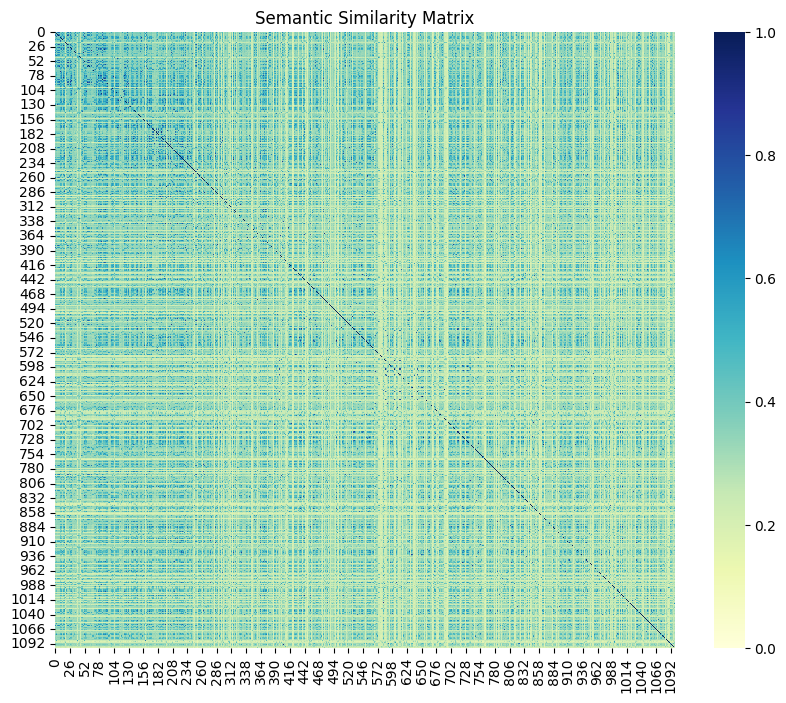

,0,1,2,3,4,5,6,7,8,9,...,1090,1091,1092,1093,1094,1095,1096,1097,1098,1099
0,1.00,0.77,0.39,0.55,0.64,0.39,0.73,0.69,0.37,0.38,...,0.23,0.34,0.35,0.39,0.34,0.34,0.32,0.25,0.29,0.19
1,0.77,1.00,0.39,0.55,0.65,0.39,0.75,0.71,0.38,0.39,...,0.21,0.34,0.36,0.38,0.34,0.34,0.32,0.27,0.30,0.18
2,0.39,0.39,1.00,0.40,0.39,0.52,0.40,0.40,0.76,0.39,...,0.23,0.34,0.34,0.40,0.45,0.32,0.31,0.27,0.32,0.20
3,0.55,0.55,0.40,1.00,0.55,0.37,0.55,0.53,0.37,0.36,...,0.22,0.31,0.34,0.38,0.34,0.32,0.32,0.35,0.30,0.21
4,0.64,0.65,0.39,0.55,1.00,0.41,0.67,0.64,0.36,0.40,...,0.20,0.33,0.34,0.37,0.34,0.33,0.31,0.24,0.27,0.18
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1095,0.34,0.34,0.32,0.32,0.33,0.33,0.34,0.34,0.32,0.35,...,0.23,0.32,0.32,0.29,0.32,1.00,0.30,0.25,0.29,0.23
1096,0.32,0.32,0.31,0.32,0.31,0.32,0.31,0.31,0.29,0.31,...,0.27,0.30,0.33,0.30,0.30,0.30,1.00,0.28,0.34,0.21
1097,0.25,0.27,0.27,0.35,0.24,0.26,0.24,0.24,0.27,0.27,...,0.20,0.41,0.43,0.25,0.23,0.25,0.28,1.00,0.28,0.23
1098,0.29,0.30,0.32,0.30,0.27,0.28,0.28,0.28,0.31,0.30,...,0.34,0.30,0.31,0.28,0.27,0.29,0.34,0.28,1.00,0.21


In [20]:
print("Term-term semantic similarity matrix:")
plt.figure(figsize=(10, 8))
sns.heatmap(semantic_similarity, cmap="YlGnBu", vmin=0, vmax=1)
plt.title("Semantic Similarity Matrix")
plt.show()

display(semantic_similarity.round(2))


In [21]:
print("Clustered term table:")
display(
    cluster[
        [
            "canonical_source",
            "name",
            "standardized_name",
            "resolved_name",
            "cluster_id",
            "cluster_label",
            "semantic_similarity_max",
        ]
    ].sort_values(["cluster_id", "canonical_source"])
)


Clustered term table:


,canonical_source,name,standardized_name,resolved_name,cluster_id,cluster_label,semantic_similarity_max
990,GO:BP,skeletal muscle cell differentiation,skeletal muscle cell differentiation,skeletal muscle cell differentiation,0,catabolism of skeletal muscle in cachexia,0.456508
314,WP,Catabolism of skeletal muscle in cachexia,catabolism of skeletal muscle in cachexia,catabolism of skeletal muscle in cachexia,0,catabolism of skeletal muscle in cachexia,0.428169
1040,GO:BP,skeletal muscle organ development,skeletal muscle organ development,skeletal muscle organ development,1,exercise and hypertrophy in skeletal muscle,0.457847
553,WP,Exercise and hypertrophy in skeletal muscle,exercise and hypertrophy in skeletal muscle,exercise and hypertrophy in skeletal muscle,1,exercise and hypertrophy in skeletal muscle,0.457847
971,GO:BP,skeletal muscle tissue development,skeletal muscle tissue development,skeletal muscle tissue development,2,skeletal muscle tissue development,0.437927
...,...,...,...,...,...,...,...
745,GO:BP,in utero embryonic development,in utero embryonic development,in utero embryonic development,895,in utero embryonic development,0.369392
465,GO:BP,positive regulation of transport,positive regulation of transport,positive regulation of transport,896,positive regulation of transport,0.360676
1008,GO:BP,blood coagulation,blood coagulation,blood coagulation,897,blood coagulation,0.329728
840,GO:BP,hepaticobiliary system development,hepaticobiliary system development,hepaticobiliary system development,898,hepaticobiliary system development,0.347897


Database-level cluster consistency matrix:


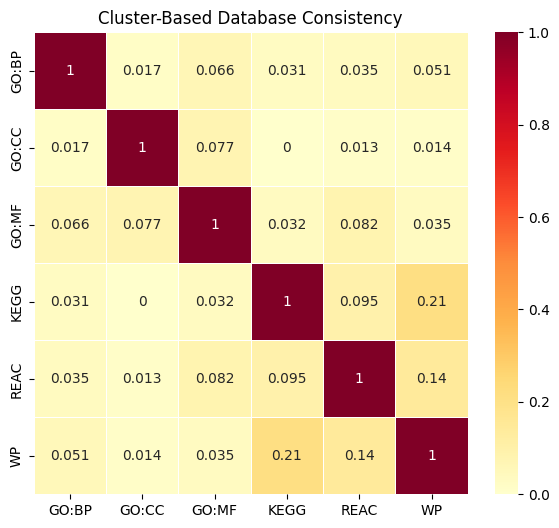

,GO:BP,GO:CC,GO:MF,KEGG,REAC,WP
GO:BP,1.00,0.02,0.07,0.03,0.04,0.05
GO:CC,0.02,1.00,0.08,0.00,0.01,0.01
GO:MF,0.07,0.08,1.00,0.03,0.08,0.03
KEGG,0.03,0.00,0.03,1.00,0.09,0.21
REAC,0.04,0.01,0.08,0.09,1.00,0.14
WP,0.05,0.01,0.03,0.21,0.14,1.00


In [22]:
print("Database-level cluster consistency matrix:")
plt.figure(figsize=(7, 6))
sns.heatmap(
    cluster_consistency,
    annot=True,
    cmap="YlOrRd",
    vmin=0,
    vmax=1,
    linewidths=0.5,
)
plt.title("Cluster-Based Database Consistency")
plt.show()

display(cluster_consistency.round(2))
